<a href="https://colab.research.google.com/github/Sagna112/zinc-flotation-recovery-prediction/blob/main/zinc_flotation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving zinc_flotation_dataset.csv to zinc_flotation_dataset.csv


In [ ]:
import pandas as pd

# Loading the dataset into a DataFrame
df = pd.read_csv('zinc_flotation_dataset.csv')

# Display the first 5 rows
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head()


#IT GENERATED FIRST 5 ROWS OF THE DATASET TO SEE IF IT's valid data

Dataset shape: 1000 rows × 8 columns



,Feed_Grade_%Zn,pH,Collector_Dosage_g_t,Frother_Dosage_g_t,Air_Flow_Rate_m3_min,Impeller_Speed_RPM,Flotation_Time_min,Zinc_Recovery_%
0,5.48,8.60,58.5,17.3,22.7,1592,23.5,55.21
1,1.22,8.87,52.6,38.1,19.2,1633,21.2,49.65
2,4.81,9.38,102.5,49.5,8.1,1725,9.0,66.81
3,2.51,11.55,34.3,25.9,15.2,1252,20.1,79.01
4,6.65,11.42,95.1,58.5,15.6,1465,12.3,96.51


In [ ]:
# Count missing values in each column
# print(df.isnull().sum())

# OR
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent
})

print(missing_summary)

#this cell code shows if there is any missing figure in the data

                      Missing Count  Missing Percentage (%)
Feed_Grade_%Zn                    0                     0.0
pH                                0                     0.0
Collector_Dosage_g_t              0                     0.0
Frother_Dosage_g_t                0                     0.0
Air_Flow_Rate_m3_min              0                     0.0
Impeller_Speed_RPM                0                     0.0
Flotation_Time_min                0                     0.0
Zinc_Recovery_%                   0                     0.0


Dataset shape: 1000 rows × 8 columns


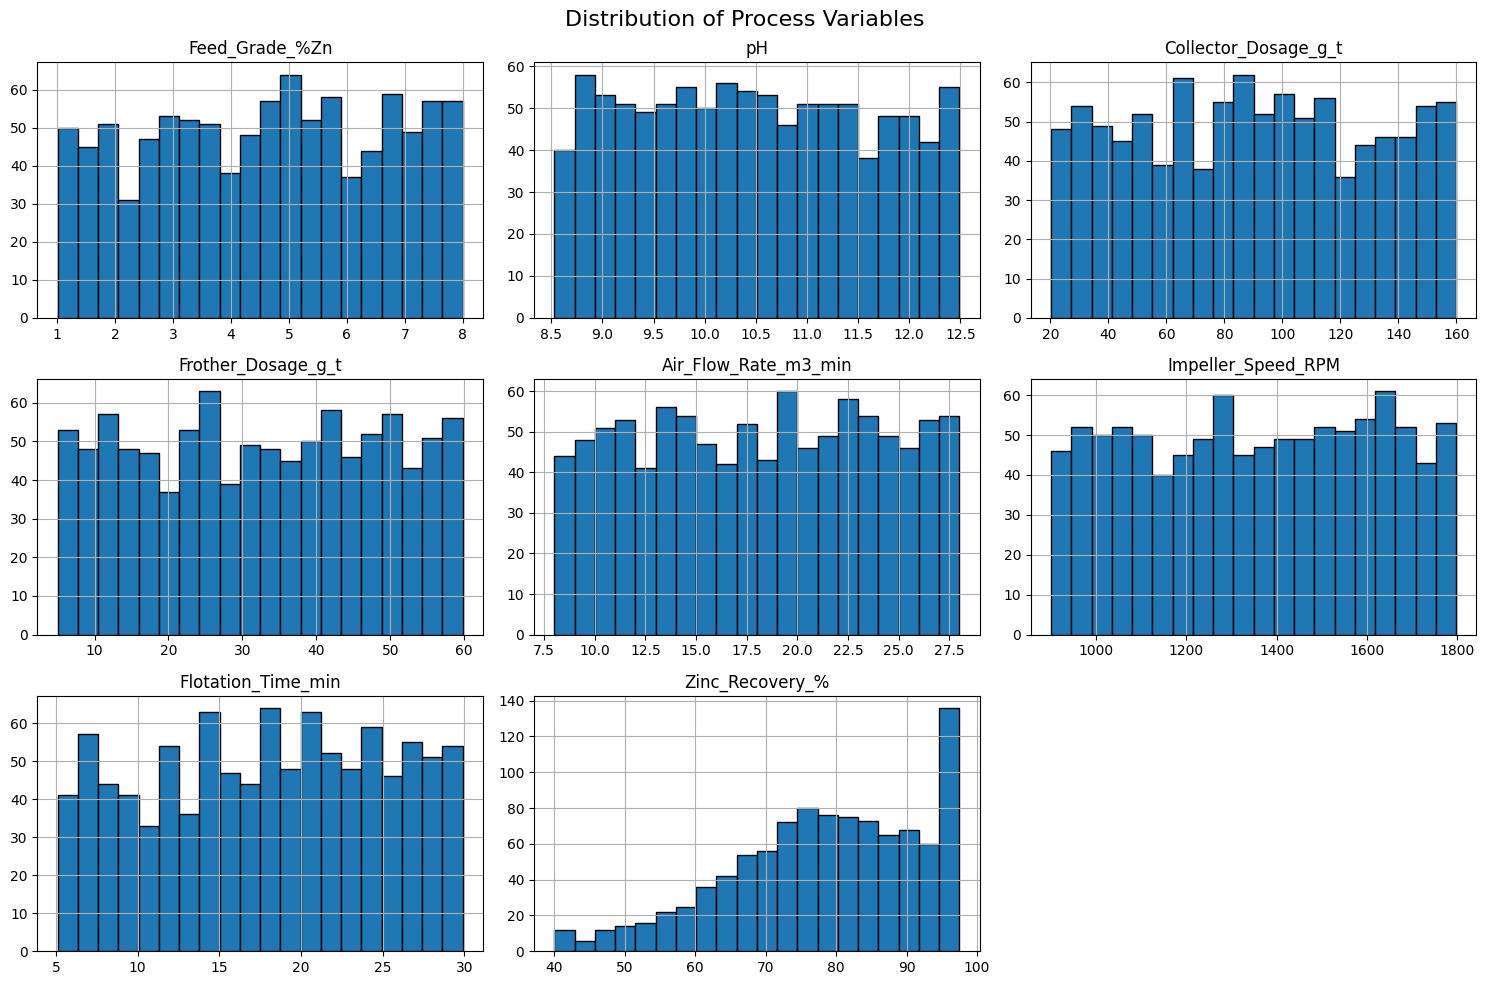

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# df = pd.read_csv('zinc_flotation_dataset.csv')

# Show dataset size
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Histograms
df.hist(
    bins=20,
    figsize=(15,10),
    edgecolor='black'
)

plt.suptitle('Distribution of Process Variables', fontsize=16)
plt.tight_layout()
plt.show()


#this code shows the histogram of each variables questions to ask here are
# is it symmetric or skewed , Are there outliers?

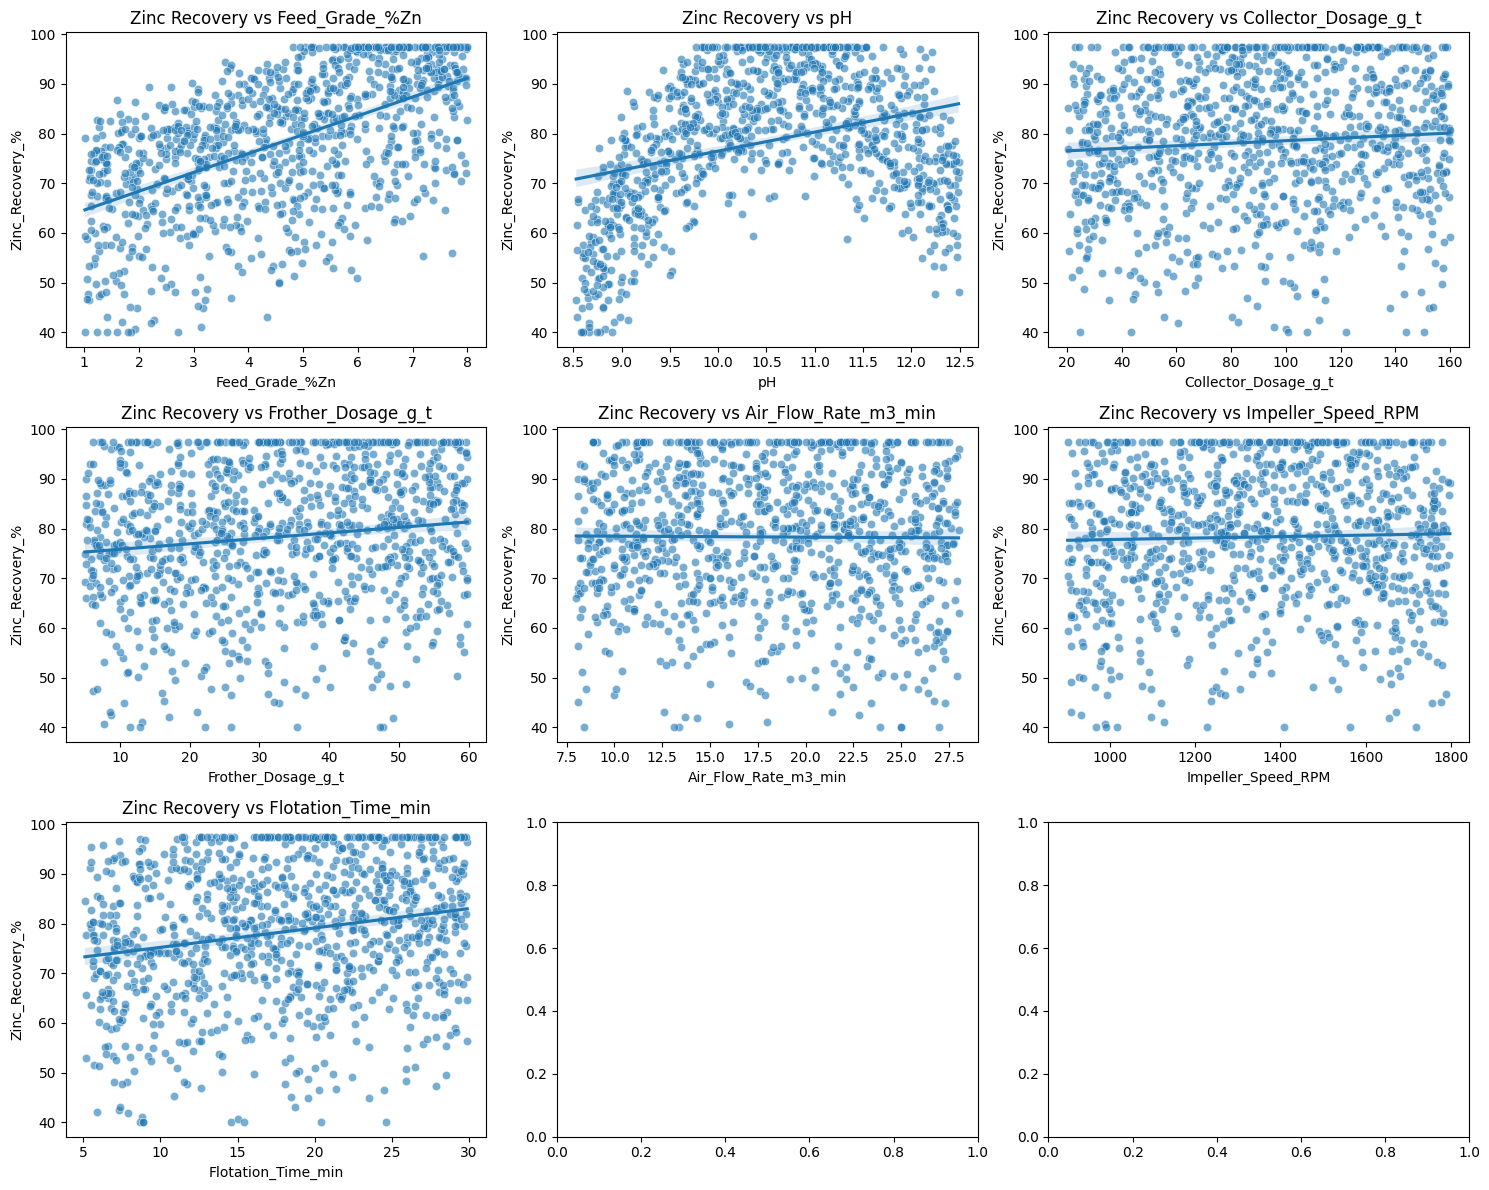

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'Feed_Grade_%Zn',
    'pH',
    'Collector_Dosage_g_t',
    'Frother_Dosage_g_t',
    'Air_Flow_Rate_m3_min',
    'Impeller_Speed_RPM',
    'Flotation_Time_min'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for var, ax in zip(variables, axes.flatten()):
    sns.scatterplot(data=df, x=var, y='Zinc_Recovery_%', alpha=0.6, ax=ax)

    sns.regplot(
        data=df,
        x=var,
        y='Zinc_Recovery_%',
        scatter=False,
        ax=ax
    )

    ax.set_title(f'Zinc Recovery vs {var}')

plt.tight_layout()
plt.show()

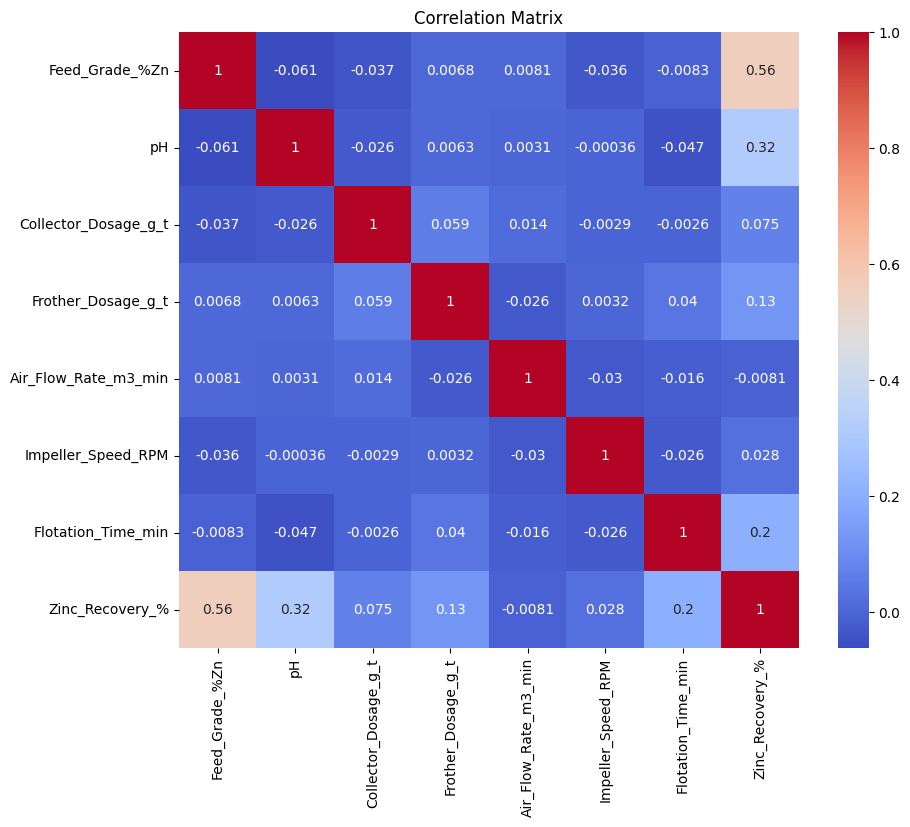

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()